In [1]:
import torch
from gpt_model import GPTModel
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256,
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
"qkv_bias": False
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

GPTModel(
  (token_embeddings): Embedding(50257, 768)
  (position_embeddings): Embedding(256, 768)
  (drop_embeddings): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (transformer): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForwardNetwork(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )


In [3]:
import os
import urllib.request
file_path = "the-verdict.txt"
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/""main/ch02/01_main-chapter-code/the-verdict.txt")
if not os.path.exists(file_path):
    with urllib.request.urlopen(url ) as response:
        text_data= response.read().decode('utf-8')
    with open (file_path, 'w', encoding='utf-8') as file:
        file.write(text_data)

else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()
        


In [4]:
from dataloader_v1 import create_dataloader_v1
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
torch.manual_seed(123)
train_loader = create_dataloader_v1(text_data[:split_idx],batch_size=2,max_length=GPT_CONFIG_124M["context_length"],stride=GPT_CONFIG_124M["context_length"],drop_last=True,shuffle=True,num_workers=0)
val_loader = create_dataloader_v1(
text_data[split_idx:],
batch_size=2,
max_length=GPT_CONFIG_124M["context_length"],
stride=GPT_CONFIG_124M["context_length"],
drop_last=False,
shuffle=False,
num_workers=0
)

### Learning rate warmup

Implementing a learning rate warmup can stabilize the training of complex models
such as LLMs. This process involves gradually increasing the learning rate from a very
low initial value (initial_lr) to a maximum value specified by the user (peak_lr).
Starting the training with smaller weight updates decreases the risk of the model
encountering large, destabilizing updates during its training phase.

In [6]:
num_epochs=15
initial_lr=0.0001
peak_lr= 0.01
warmup_steps=20
total_steps= len(train_loader) * num_epochs
print(total_steps)
warmup_steps = int(0.2 * total_steps)
print(warmup_steps)

120
24


In [8]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment= (peak_lr- initial_lr) / warmup_steps
global_step=-1
track_lrs=[]

for epoch in range(num_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

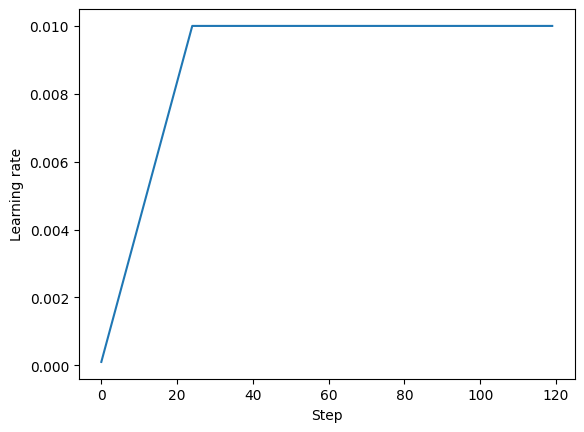

In [9]:
import matplotlib.pyplot as plt
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * num_epochs
plt.plot(range(total_training_steps), track_lrs);
plt.show()


### Cosine Decay

Another widely adopted technique for training complex deep neural networks and
LLMs is cosine decay. This method modulates the learning rate throughout the training
epochs, making it follow a cosine curve after the warmup stage.
In its popular variant, cosine decay reduces (or decays) the learning rate to nearly
zero, mimicking the trajectory of a half-cosine cycle. The gradual learning decrease in
cosine decay aims to decelerate the pace at which the model updates its weights. This
is particularly important because it helps minimize the risk of overshooting the loss
minima during the training process, which is essential for ensuring the stability of the
training during its later phases

In [14]:
import math
min_lr= 0.1 * initial_lr
track_lrs=[]
lr_increment= (peak_lr- initial_lr) / warmup_steps
global_step=-1
for epoch in range(num_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            percent= ((global_step - warmup_steps) / (total_steps- warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * percent))
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

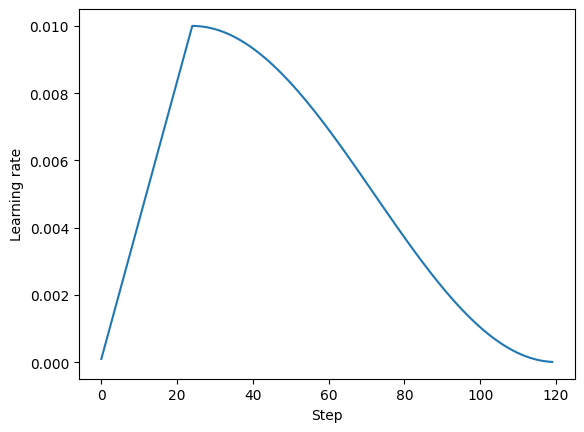

In [15]:
plt.ylabel("Learning rate")
plt.xlabel("Step")
plt.plot(range(total_training_steps), track_lrs)
plt.show()

The resulting learning rate plot shows that the learning rate starts with a linear warmup
phase, which increases for 20 steps until it reaches the maximum value after 20 steps.
After the 20 steps of linear warmup, cosine decay kicks in, reducing the learning rate
gradually until it reaches its minimu

### Gradient Clipping

Gradient clipping is another important technique for enhancing stability during LLM
training. This method involves setting a threshold above which gradients are down-
scaled to a predetermined maximum magnitude. This process ensures that the updates
to the model’s parameters during backpropagation stay within a manageable range.
For example, applying the max_norm=1.0 setting within PyTorch’s clip_grad_
norm_ function ensures that the norm of the gradients does not surpass 1.0. Here, the
term “norm” signifies the measure of the gradient vector’s length, or magnitude,
within the model’s parameter space, specifically referring to the L2 norm, also known
as the Euclidean norm.

In [18]:
from model_training_utlilities import calc_loss_batch
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
loss = calc_loss_batch(input_batch, target_batch, device, model)
loss.backward()

In [21]:
def find_max_grad(model):
    max_grad = None
    for param in model.parameters():
        if param.grad is not None:
            grad_values= param.grad.data.flatten()
            max_grad_param= grad_values.max()
            if max_grad is None or max_grad_param > max_grad:
                max_grad = max_grad_param
    return max_grad
print(find_max_grad(model))

tensor(0.0378)


In [23]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_max_grad(model))

tensor(0.0174)


now we finally implement the training function which encompasses all these concepts together

In [ ]:

from model_training_utlilities  import generate_and_print_sample,evaluate_model
def train_model(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer, warmup_steps, initial_lr=3e-05, min_lr=1e-6):
    train_losses, val_losses, track_tokens_seen, track_lrs= [],[],[],[]
    tokens_seen, global_step= 0, -1
    peak_lr = optimizer.param_groups[0]["lr"]
    total_training_steps = len(train_loader) * n_epochs
    lr_increment = (peak_lr - initial_lr) / warmup_steps
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1
            if global_step < warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = ((global_step - warmup_steps) /(total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)
            loss = calc_loss_batch(input_batch, target_batch, device, model)
            loss.backward()
            if global_step > warmup_steps:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            tokens_seen += input_batch.numel()
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader,device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                f"Train loss {train_loss:.3f}, "
                f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen, track_lrs

In [30]:
import tiktoken
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
peak_lr = 5e-4
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
tokenizer = tiktoken.get_encoding("gpt2")
n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model(
model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs,
eval_freq=5, eval_iter=1, start_context="Every effort moves you",
tokenizer=tokenizer, warmup_steps=warmup_steps,
initial_lr=1e-5, min_lr=1e-5
)

NameError: name 'evaluate_model' is not defined